# 文件: chart_87_1.py

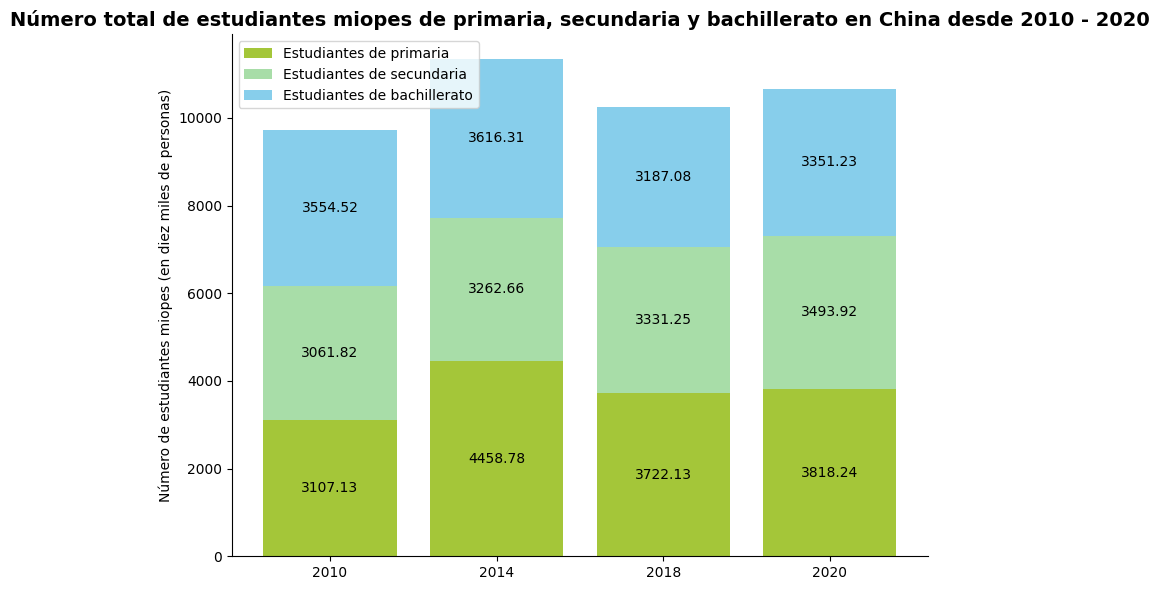

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Años
años = ["2010", "2014", "2018", "2020"]
# Número de estudiantes miopes en cada etapa educativa (en diez miles de personas), 
# los datos son consistentes con los niveles correspondientes en el gráfico y se pueden ajustar según sea necesario
datos = {
    "Estudiantes de primaria": [3107.13, 4458.78, 3722.13, 3818.24],
    "Estudiantes de secundaria": [3061.82, 3262.66, 3331.25, 3493.92],
    "Estudiantes de bachillerato": [3554.52, 3616.31, 3187.08, 3351.23]
}
# Configuración de colores para coincidir con el esquema de colores del gráfico
colores = ["#A4C639", "#a8dda8", "#87CEEB"]  

# Crear un lienzo
fig, ax = plt.subplots(figsize=(8, 6))

# Dibujar un gráfico de barras apiladas
base = np.zeros(len(años))
for i, (categoria, valores) in enumerate(datos.items()):
    ax.bar(años, valores, bottom=base, color=colores[i], label=categoria)
    # Agregar etiquetas de datos
    for x, y in zip(np.arange(len(años)), valores):
        ax.text(x, base[x] + y / 2, f'{y}', ha='center', va='center', color='black')
    base += np.array(valores)

# Establecer la etiqueta del eje y
ax.set_ylabel("Número de estudiantes miopes (en diez miles de personas)")
# Establecer el título
ax.set_title('Número total de estudiantes miopes de primaria, secundaria y bachillerato en China desde 2010 - 2020', fontsize=14, fontweight='bold')

# Agregar una leyenda
ax.legend()

# Mejora visual: Ocultar los bordes superior y derecho
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

# 文件: chart_87_2.py

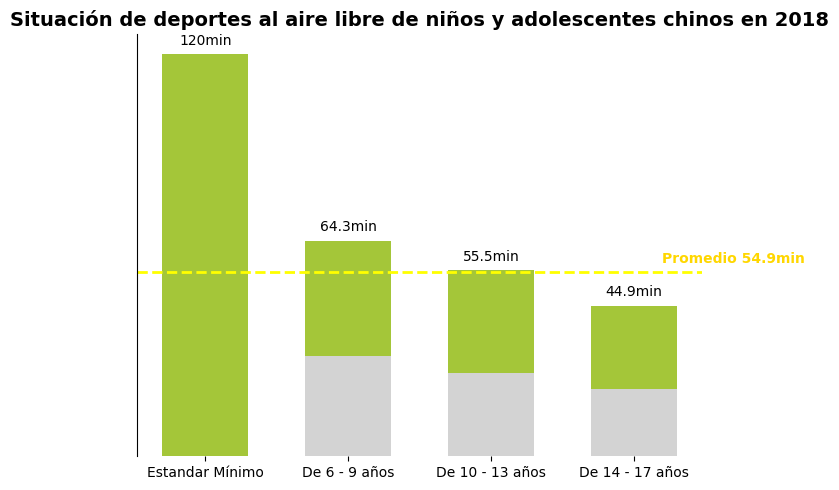

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Categorías
categorias = ["Estandar Mínimo", "De 6 - 9 años", "De 10 - 13 años", "De 14 - 17 años"]
# Datos (mínimos), correspondientes al gráfico
datos = [120, 64.3, 55.5, 44.9]
# La parte que alcanza el promedio en cada categoría (valor esquemático, que coincide con el efecto visual del gráfico)
partes_promedio = [120, 30, 25, 20]
# Configuración de colores
colores = ["#A4C639", "#D3D3D3", "#D3D3D3", "#D3D3D3"]
linea_promedio_y = 54.9  # Duración promedio

# Crear un lienzo
fig, ax = plt.subplots(figsize=(7, 5))

# Dibujar un gráfico de barras
x = np.arange(len(categorias))
ancho_barra = 0.6
for i in range(len(categorias)):
    # Dibujar la parte inferior (gris o verde)
    rect = ax.bar(x[i], datos[i], width=ancho_barra, color=colores[i])
    # Dibujar la "parte del promedio" cubierta en la parte superior (solo el estándar mínimo no necesita ser cubierto porque es verde y supera el promedio)
    if categorias[i] != "Estandar Mínimo":
        ax.bar(x[i], datos[i] - partes_promedio[i], bottom=partes_promedio[i], width=ancho_barra, color=colores[0])
    # Agregar etiquetas de datos
    ax.text(x[i], datos[i] + 2, f'{datos[i]}min', ha='center', va='bottom', color='black')

# Dibujar una línea punteada amarilla para la duración promedio
ax.axhline(y=linea_promedio_y, color='yellow', linestyle='--', linewidth=2)
ax.text(3.2, linea_promedio_y + 2, f'Promedio {linea_promedio_y}min', ha='left', va='bottom', color='gold', fontweight='bold')

# Establecer las marcas y etiquetas del eje x
ax.set_xticks(x)
ax.set_xticklabels(categorias)
# Ocultar las marcas del eje y
ax.set_yticks([])
# Establecer el título
ax.set_title('Situación de deportes al aire libre de niños y adolescentes chinos en 2018', fontsize=14, fontweight='bold')

# Embelezar: ocultar los bordes superior, derecho e inferior
for spine in ['top', 'right', 'bottom']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

# 文件: chart_87_3.py

C:\Users\tomatoyuan\AppData\Local\Temp\ipykernel_40128\3591688706.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("autumn_r")  # Gradiente de naranja a rojo


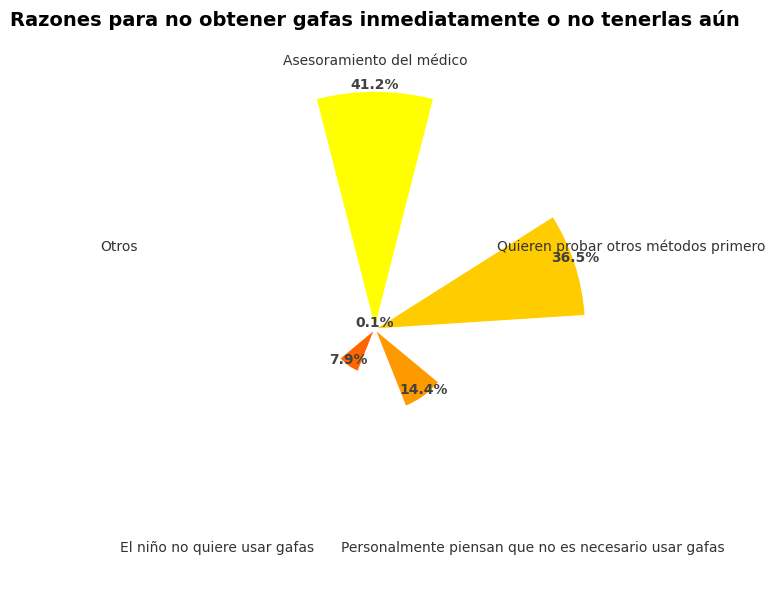

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

# -------------------- Preparación de datos --------------------
razones = [
    "Asesoramiento del médico", "Quieren probar otros métodos primero", 
    "Personalmente piensan que no es necesario usar gafas", "El niño no quiere usar gafas", "Otros"
]
porcentajes = [41.2, 36.5, 14.4, 7.9, 0.1]

# División de ángulos en coordenadas polares (un ángulo por cada categoría)
angulos = np.linspace(0, 2 * np.pi, len(razones), endpoint=False)
# Convertir datos a matriz numpy
datos = np.array(porcentajes)

# Establecer gradiente de colores
cmap = cm.get_cmap("autumn_r")  # Gradiente de naranja a rojo
colores = [cmap(i / len(datos)) for i in range(len(datos))]

# -------------------- Crear gráfico polar --------------------
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw=dict(polar=True))

# Establecer ángulo de inicio y dirección de disposición
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)

# Dibujar gráfico de barras polar
barras = ax.bar(angulos, datos, width=0.5, color=colores, edgecolor="white", linewidth=1)

# Agregar etiquetas de datos
for i, (barra, porcentaje) in enumerate(zip(barras, datos)):
    angulo = angulos[i]
    ax.text(
        angulo, barra.get_height(),
        f"{porcentaje}%",
        ha='center', va='bottom',
        fontsize=10, fontweight="bold",
        color="#424242"
    )

# Agregar etiquetas (categorías)
ax.set_xticks(angulos)
ax.set_xticklabels(razones, fontsize=10, color="#333333")

# Quitar eje polar y marcas de graduación
ax.set_yticklabels([])
ax.spines["polar"].set_visible(False)
ax.grid(False)

# Agregar título
ax.set_title("Razones para no obtener gafas inmediatamente o no tenerlas aún", fontsize=14, fontweight="bold", pad=20)

plt.tight_layout()
plt.show()

# 文件: chart_87_4.py

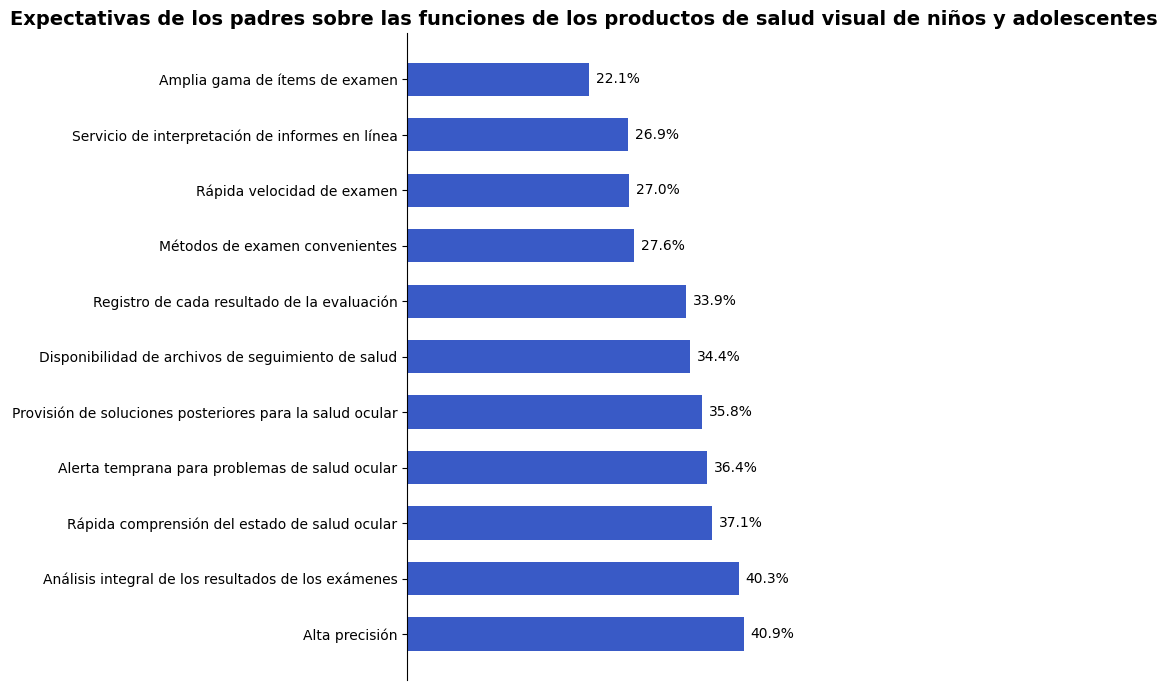

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Expectativas funcionales
funciones = [
    "Alta precisión",
    "Análisis integral de los resultados de los exámenes",
    "Rápida comprensión del estado de salud ocular",
    "Alerta temprana para problemas de salud ocular",
    "Provisión de soluciones posteriores para la salud ocular",
    "Disponibilidad de archivos de seguimiento de salud",
    "Registro de cada resultado de la evaluación",
    "Métodos de examen convenientes",
    "Rápida velocidad de examen",
    "Servicio de interpretación de informes en línea",
    "Amplia gama de ítems de examen"
]
# Porcentajes correspondientes (%), los datos son consistentes con el gráfico
porcentajes = [40.9, 40.3, 37.1, 36.4, 35.8, 34.4, 33.9, 27.6, 27.0, 26.9, 22.1]

# Crear un lienzo y un subgráfico
fig, ax = plt.subplots(figsize=(8, 7))

# Dibujar un gráfico de barras horizontales
y = np.arange(len(funciones))
ancho_barra = 0.6
barras = ax.barh(y, porcentajes, height=ancho_barra, color="#395AC6")

# Agregar etiquetas de datos
for barra in barras:
    ancho = barra.get_width()
    ax.annotate(f'{ancho}%',
                xy=(ancho, barra.get_y() + barra.get_height() / 2),
                xytext=(5, 0),  # Ajustar la posición de la etiqueta
                textcoords="offset points",
                ha='left', va='center')

# Establecer las marcas y etiquetas del eje y (ajustar el orden para que la primera función esté en la parte superior)
ax.set_yticks(y)
ax.set_yticklabels(funciones)
# Ocultar las marcas del eje x
ax.set_xticks([])
# Establecer el título
ax.set_title("Expectativas de los padres sobre las funciones de los productos de salud visual de niños y adolescentes", fontsize=14, fontweight="bold")

# Embellir el gráfico ocultando los bordes superior, derecho e inferior
for espina in ["top", "right", "bottom"]:
    ax.spines[espina].set_visible(False)

plt.tight_layout()  # Ajustar automáticamente el diseño
plt.show()